In [1]:
import glob
import joblib
from handFeaturesExtraction import preprocess_landmarks, get_freq_inten, extract_thumb_index_periods, get_thumb_index_dis
from scipy.signal import stft
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import os
from utils import clarity, find_period, find_peaks
from handExtraction import hand_extraction
import matplotlib.animation as animation
import imageio


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [7]:
v_pth = "../../Finger_Tapping_demo1.mp4"

hand_extraction(v_pth, out_video_root="../../")

30


/tmp/ipykernel_130966/2121929277.py:57: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"frames/frame_{i:04d}.png")
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 500) to (1008, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved as finger_tapping_animation.mp4


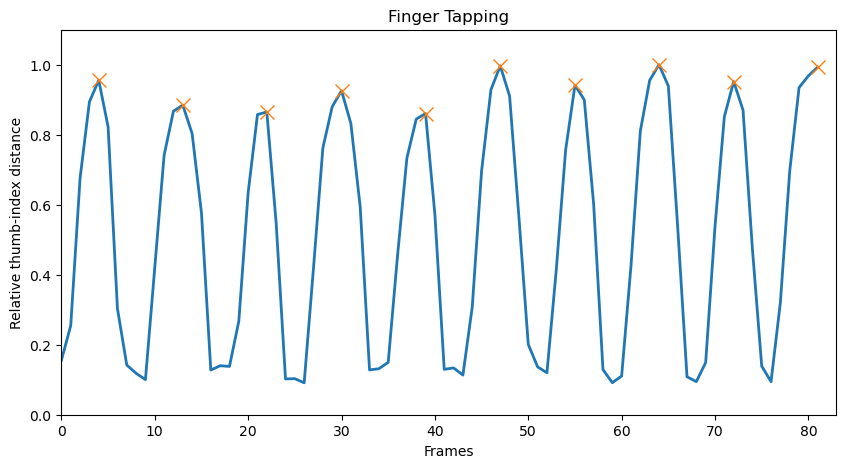

In [6]:
# Load and preprocess data
hand_pth = "../../right_hand_Finger_Tapping_demo1.txt"
dt = joblib.load(hand_pth)
arr = preprocess_landmarks(dt)[:, 0, :, :]

# Calculate thumb-index distance and normalize
hand_dis = get_thumb_index_dis(arr)
mean_hand_dis = np.mean(hand_dis)
hand_dis = hand_dis / hand_dis.max()

# Find period and peaks
T, _ = find_period(hand_dis)
p, values = find_peaks(hand_dis, height=np.mean(hand_dis), distance=int(T * 0.4))

# Set FPS and duration
fps = 30
duration = len(hand_dis) / fps

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("Frames",  fontsize=32)
ax.set_ylabel("Relative thumb-index distance",  fontsize=32)
ax.set_title("Finger Tapping",  fontsize=32)
line, = ax.plot([], [], lw=2, label="distance")
points, = ax.plot([], [], "x", ms=10, label = "Open")
ax.legend( fontsize=32)

# Initialization function
def init():
    ax.set_xlim(0, len(hand_dis))
    ax.set_ylim(0, 1.1)
    line.set_data([], [])
    points.set_data([], [])
    return line, points

# Animation function
def animate(i):
    x = np.arange(0, i)
    y = hand_dis[:i]
    line.set_data(x, y)
    points.set_data(p[p <= i], hand_dis[p[p <= i]])
    return line, points

# Create animation
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(hand_dis), interval=1000/fps, blit=True)

# Save frames
if not os.path.exists("frames"):
    os.mkdir("frames")

for i in range(len(hand_dis)):
    animate(i)
    plt.savefig(f"frames/frame_{i:04d}.png")

# Create a video from the saved frames
with imageio.get_writer('finger_tapping_animation.mp4', fps=fps) as writer:
    for i in range(len(hand_dis)):
        image = imageio.imread(f"frames/frame_{i:04d}.png")
        writer.append_data(image)

# Clean up frames directory
import shutil
shutil.rmtree("frames")

print("Video saved as finger_tapping_animation.mp4")


In [3]:
# pth = "/HDD3/PD_Data/TW/PD_Data_Hand/"
# for p,d,f  in os.walk(pth):
#     print(f)

path = "/HDD3/PD_Data/TW/PD_Data_Hand/*/*A*.mp4"
files_ls = glob.glob(path)
files_ls

['/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_22AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_13AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_13AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_7AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_5AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_1AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_3AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_12AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_10AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_7AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_8AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_16AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_8AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_4AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_11AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_9AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/2

In [5]:
path1 = r'../../handOutput/*_A*_hand.txt'
files1_ls = glob.glob(path)

path2 = r'../../handOutput2/*_A*_hand.txt'
files2_ls = glob.glob(path)

path3 = r'../../handOutput3/*_A*_hand.txt'
files3_ls = glob.glob(path)

all_ls = files1_ls + files2_ls + files3_ls
len(files3_ls)


['/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_22AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_13AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_13AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_7AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_5AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_1AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_3AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_12AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_10AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_7AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_8AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_16AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_8AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_4AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_11AL.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/20200818/20200818_9AR.mp4',
 '/HDD3/PD_Data/TW/PD_Data_Hand/2

In [116]:
set.difference(set([f.split("/")[-1][:-4].replace("_", "") for f in files_ls]), set([f.split("/")[-1][:-9].replace("_", "")  for f in files3_ls]))

set()

In [3]:
error_ls = []
path_ls = []
f_ls = []
e_ls = []
f_e_ls = []
f_dff_ls = []

for p in files3_ls:
    dt = joblib.load(p)

    try:
        dt = joblib.load(p)
        
        arr = preprocess_landmarks(dt)[:, 0, :, :]
        f, e, f_e, f_dff = get_freq_inten(arr)
        
        path_ls.append(p)
        f_ls.append(f)
        e_ls.append(e)
        f_e_ls.append(f_e)
        f_dff_ls.append(f_dff)
        
        print("Finish {}".format(p)) 

    except:
        error_ls.append(p)

dt = {
    "name": path_ls,
    "freq": f_ls,
    "intensity": e_ls,
    "freq_inten":f_e_ls,
    "freq_different": f_dff_ls
}


/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 191, using nperseg = 191
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 274, using nperseg = 274
  warnings.warn('nperseg = {0:d} is greater than input length '


Finish ../../handOutput3/20200730_10_AL_hand.txt
Finish ../../handOutput3/20200811_12_AL_hand.txt
Finish ../../handOutput3/20200618_22_AR_hand.txt
Finish ../../handOutput3/20200716_15_AR_hand.txt
Finish ../../handOutput3/20201023_2_AR_hand.txt
Finish ../../handOutput3/202007014_2_AL_hand.txt
Finish ../../handOutput3/20200611_22_AL_hand.txt
Finish ../../handOutput3/20201127_17_AR_hand.txt
Finish ../../handOutput3/20200618_13_AR_hand.txt
Finish ../../handOutput3/20200521_14_AR_hand.txt
Finish ../../handOutput3/20201218_7_AL_hand.txt
Finish ../../handOutput3/20200825_17_AL_hand.txt


/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 298, using nperseg = 298
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 167, using nperseg = 167
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 181, using nperseg = 181
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 118, using nperseg = 118
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/leo/miniconda3/envs/pdmodel/li

Finish ../../handOutput3/20200604_13_AL_hand.txt
Finish ../../handOutput3/20201110_1_AR_hand.txt
Finish ../../handOutput3/20200915_15_AL_hand.txt
Finish ../../handOutput3/20200915_1_AL_hand.txt
Finish ../../handOutput3/20201023_8_AR_hand.txt
Finish ../../handOutput3/20200723_15_AL_hand.txt
Finish ../../handOutput3/20200604_5_AL_hand.txt
Finish ../../handOutput3/20200528_12_AR_hand.txt
Finish ../../handOutput3/20200604_10_AR_hand.txt
Finish ../../handOutput3/20201103_4_AL_hand.txt
Finish ../../handOutput3/20200818_17_AR_hand.txt
Finish ../../handOutput3/20200806_11_AR_hand.txt
Finish ../../handOutput3/20200707_7_AL_hand.txt
Finish ../../handOutput3/20200702_24_AR_hand.txt
Finish ../../handOutput3/20201124_2_AL_hand.txt
Finish ../../handOutput3/20201127_15_AL_hand.txt
Finish ../../handOutput3/202007014_10_AR_hand.txt
Finish ../../handOutput3/20201029_4_AL_hand.txt


/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 196, using nperseg = 196
  warnings.warn('nperseg = {0:d} is greater than input length '


...

Finish ../../handOutput3/20200818_11_AR_hand.txt
Finish ../../handOutput3/20200915_15_AR_hand.txt
Finish ../../handOutput3/20200709_16_AR_hand.txt
Finish ../../handOutput3/20200528_4_AR_hand.txt
Finish ../../handOutput3/20200521_12_AL_hand.txt
Finish ../../handOutput3/20201211_5_AR_hand.txt
Finish ../../handOutput3/20200730_3_AR_hand.txt
Finish ../../handOutput3/20201029_4_AR_hand.txt
Finish ../../handOutput3/20200908_9_AL_hand.txt
Finish ../../handOutput3/20200618_9_AL_hand.txt
Finish ../../handOutput3/20200611_4_AR_hand.txt
Finish ../../handOutput3/20200915_5_AR_hand.txt
Finish ../../handOutput3/20200514_2_AL_hand.txt
Finish ../../handOutput3/20200702_19_AL_hand.txt
Finish ../../handOutput3/20201023_9_AR_hand.txt
Finish ../../handOutput3/20201023_14_AR_hand.txt
Finish ../../handOutput3/20200528_4_AL_hand.txt
Finish ../../handOutput3/20201015_6_AL_hand.txt
Finish ../../handOutput3/20200811_5_AR_hand.txt
Finish ../../handOutput3/20201218_10_AR_hand.txt
Finish ../../handOutput3/20200915

/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 291, using nperseg = 291
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 219, using nperseg = 219
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 237, using nperseg = 237
  warnings.warn('nperseg = {0:d} is greater than input length '


Finish ../../handOutput3/20200702_4_AR_hand.txt
Finish ../../handOutput3/20200915_3_AR_hand.txt
Finish ../../handOutput3/20200521_5_AL_hand.txt
Finish ../../handOutput3/20200521_6_AL_hand.txt
Finish ../../handOutput3/20200604_6_AL_hand.txt
Finish ../../handOutput3/20201127_12_AR_hand.txt
Finish ../../handOutput3/20200528_10_AR_hand.txt
Finish ../../handOutput3/20201211_4_AR_hand.txt
Finish ../../handOutput3/20200618_20_AL_hand.txt


/home/leo/miniconda3/envs/pdmodel/lib/python3.8/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 300 is greater than input length  = 158, using nperseg = 158
  warnings.warn('nperseg = {0:d} is greater than input length '


Finish ../../handOutput3/20200716_11_AR_hand.txt
Finish ../../handOutput3/20200915_11_AL_hand.txt
Finish ../../handOutput3/20200716_9_AR_hand.txt
Finish ../../handOutput3/20200818_12_AR_hand.txt
Finish ../../handOutput3/20201229_2_AR_hand.txt
Finish ../../handOutput3/20200514_8_AR_hand.txt
Finish ../../handOutput3/20200908_8_AR_hand.txt
Finish ../../handOutput3/20200611_18_AL_hand.txt
Finish ../../handOutput3/20200702_19_AR_hand.txt
Finish ../../handOutput3/20200709_20_AL_hand.txt
Finish ../../handOutput3/20200818_15_AR_hand.txt
Finish ../../handOutput3/20200611_6_AL_hand.txt
Finish ../../handOutput3/20200716_4_AL_hand.txt
Finish ../../handOutput3/20201201_1_AL_hand.txt


In [4]:
df = pd.DataFrame.from_dict(dt)
df["Date"]= df["name"].apply(lambda x: x.split("/")[-1].split("_")[0])
df["PID"] = df["name"].apply(lambda x: x.split("/")[-1].split("_")[1])
df["Hand"] = df["name"].apply(lambda x: x.split("/")[-1].split("_")[2][-1])
df["Date"] = df["Date"].apply(lambda x : str(x[0:4]) + "-" + str(x[4:6]) + "-" + str(x[6:]))
df["PID"] = df["PID"].astype(int)
df = df.set_index(["Date", "PID"])
h_g = df.groupby("Hand")
left = h_g.get_group("L").loc[:, ['freq', 'intensity', 'freq_inten', 'freq_different']]
right = h_g.get_group("R").loc[:, ['freq', 'intensity', 'freq_inten', 'freq_different']]
left.columns = ['l_freq', 'l_intensity', 'l_freq_inten', 'l_freq_different' ]
right.columns = ['r_freq', 'r_intensity', 'r_freq_inten', 'r_freq_different']

new_hand_df = left.join(right)

In [5]:
new_hand_df

,,l_freq,l_intensity,l_freq_inten,l_freq_different,r_freq,r_intensity,r_freq_inten,r_freq_different
Date,PID,,,,,,,,
2020-07-30,10,4.202643,0.214877,0.903050,-0.416447,4.064975,0.136612,0.555326,0.581158
2020-08-11,12,4.360041,0.048999,0.213636,0.816428,4.249808,0.079824,0.339235,-0.198778
2020-07-014,2,1.941725,0.134691,0.261534,-0.300801,2.177138,0.118415,0.257806,-0.341318
2020-06-11,22,2.547858,0.228683,0.582653,0.170893,3.107206,0.349468,1.085869,-0.940509
2020-12-18,7,2.951147,0.144391,0.426118,-1.339012,2.167540,0.208155,0.451183,-0.847546
...,...,...,...,...,...,...,...,...,...
2020-06-11,18,2.053178,0.132325,0.271686,0.651601,2.122175,0.144039,0.305675,-0.833972
2020-07-09,20,2.336512,0.137789,0.321945,-1.032437,2.873282,0.124554,0.357878,-0.048575
2020-06-11,6,2.636689,0.307033,0.809551,0.067645,2.262024,0.294157,0.665389,-0.299130


In [6]:
hand_prev_df =pd.read_csv("../../hand_train_20221124_v3.csv", index_col=["Date", "PID"])
gait_df =pd.read_csv("../../gait_train_20221124_v3.csv", index_col=["Date", "PID"])
vioce_df =pd.read_csv("../../voice_train_20221124_v3.csv", index_col=["Date", "PID"]).iloc[:, 2:-1]
test_df = pd.read_csv("../../held_off_test_20221124_v3.csv", index_col=["Date", "PID"]).iloc[:, 2:-1]
new_hand_train_df = hand_prev_df.join(new_hand_df)
new_hand_train_df = new_hand_train_df.loc[:, ['r_thumb_index_t', 'r_thumb_index_c',
       'r_thumb_index_d', 'l_thumb_index_t', 'l_thumb_index_c',
       'l_thumb_index_d', 'l_freq', 'l_intensity', 'l_freq_inten',
       'l_freq_different', 'r_freq', 'r_intensity', 'r_freq_inten',
       'r_freq_different',]]
new_test_df = test_df.join(new_hand_df).dropna()


In [30]:
train_df = pd.concat([gait_df, vioce_df, new_hand_train_df], axis=1)
train_df = train_df.loc[:, ['Age', 'Gender', 'left_foot_ground', 'right_foot_ground',
       'left_right_foot_len_average', 'left_right_foot_len_max',
       'left_turning_duration', 'left_turning_slope', 'right_turning_duration',
       'right_turning_slope', 'l_leg_max_angles', 'l_leg_min_angles',
       'r_leg_max_angles', 'r_leg_min_angles', 'l_arm_max_angles',
       'l_arm_min_angles', 'r_arm_max_angles', 'r_arm_min_angles',
       'core_max_angles', 'core_min_angles', 'average_duration_per_rounds',
       'duration_change', 'l_mean_steps', 'r_mean_steps',
       'read time', 'score', 'pause(%)', 'volume change', 'pitch change',
       'Average pitch', 'r_thumb_index_t', 'r_thumb_index_c',
       'r_thumb_index_d', 'l_thumb_index_t', 'l_thumb_index_c',
       'l_thumb_index_d', 'l_freq', 'l_intensity', 'l_freq_inten',
       'l_freq_different', 'r_freq', 'r_intensity', 'r_freq_inten',
       'r_freq_different',  'PD Stages']]

train_df["PD Stages"] = train_df["PD Stages"].apply(lambda x: 0 if x == 0 else 1 if x in [1, 2] else 2)

In [31]:
gait_col = [ 'left_foot_ground', 'right_foot_ground',
       'left_right_foot_len_average', 'left_right_foot_len_max',
       'left_turning_duration', 'left_turning_slope', 'right_turning_duration',
       'right_turning_slope', 'l_leg_max_angles', 'l_leg_min_angles',
       'r_leg_max_angles', 'r_leg_min_angles', 'l_arm_max_angles',
       'l_arm_min_angles', 'r_arm_max_angles', 'r_arm_min_angles',
       'core_max_angles', 'core_min_angles', 'average_duration_per_rounds',
       'duration_change', 'l_mean_steps', 'r_mean_steps',]

hand_col = ['r_thumb_index_t', 'r_thumb_index_c',
       'r_thumb_index_d', 'l_thumb_index_t', 'l_thumb_index_c',
       'l_thumb_index_d', 'l_freq', 'l_intensity', 'l_freq_inten',
       'l_freq_different', 'r_freq', 'r_intensity', 'r_freq_inten',
       'r_freq_different']

voice_col = [ 'read time', 'score', 'pause(%)', 'volume change', 'pitch change',
       'Average pitch']


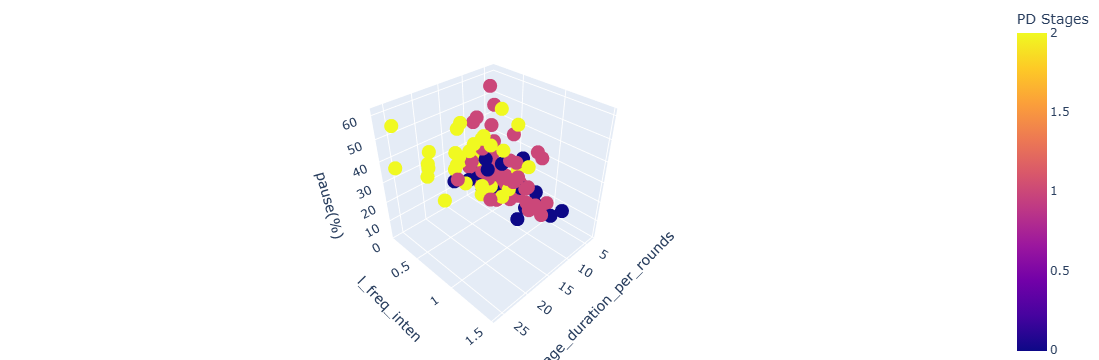

In [32]:

fig = px.scatter_3d(train_df, x='average_duration_per_rounds', y='l_freq_inten', z='pause(%)',
              color='PD Stages', size_max=10)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

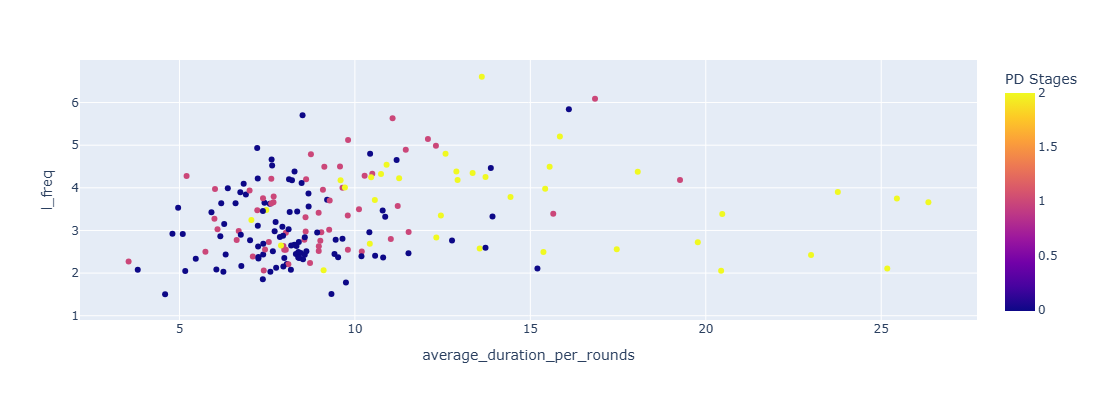

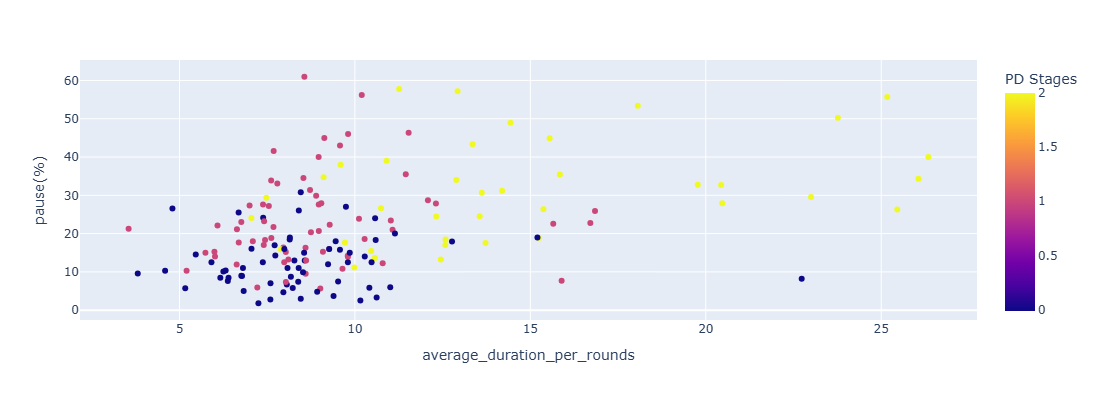

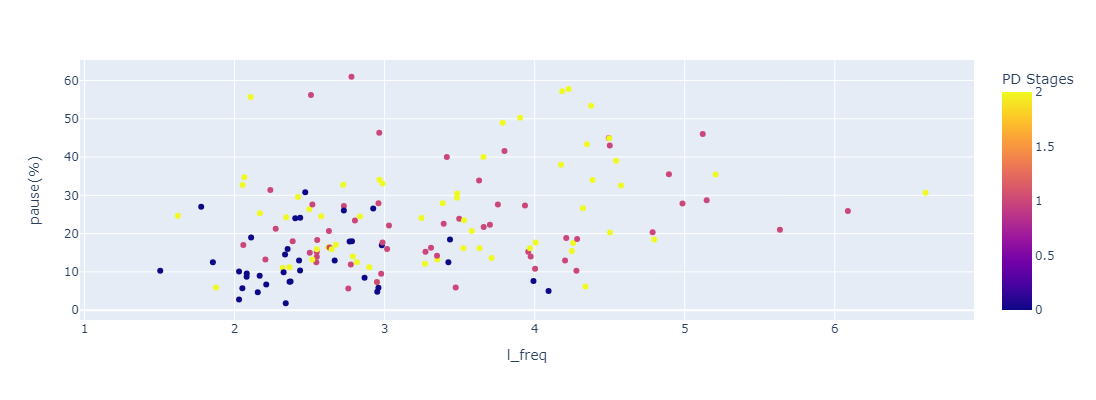

In [33]:
from itertools import combinations
ls =  ['average_duration_per_rounds', 'l_freq', 'pause(%)']
for l in list(combinations(ls, 2)):
    fig = px.scatter(train_df, x=l[0], y=l[1], width=400, height=400,  color='PD Stages')
    fig.show()

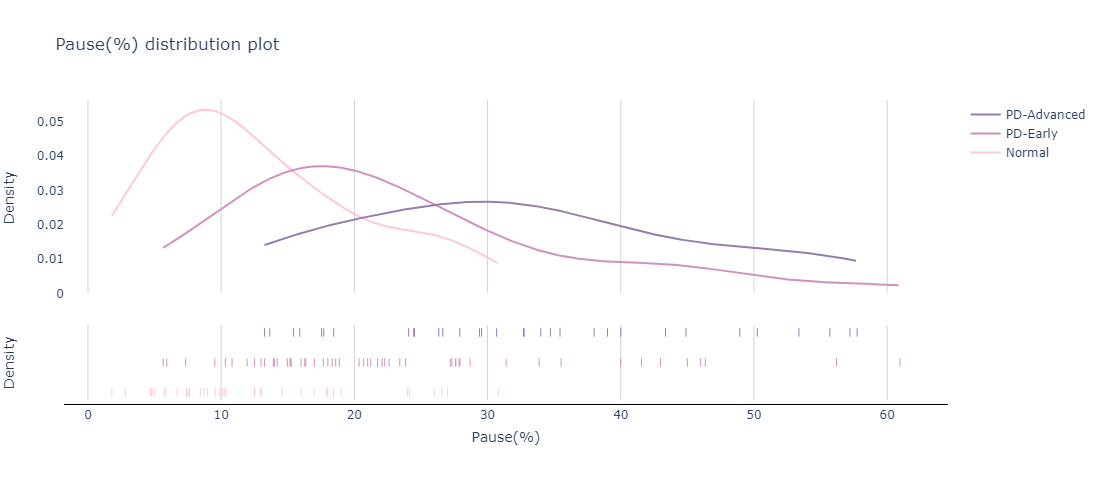

In [61]:
import plotly.figure_factory as ff
train_df = train_df.dropna()
t_g = train_df.groupby("PD Stages")
hist_data = [
    t_g.get_group(0)["pause(%)"],
    t_g.get_group(1)["pause(%)"],
    t_g.get_group(2)["pause(%)"],
]
group_labels = ['Normal', 'PD-Early', 'PD-Advanced']
colors = ['#FEC8D8 ', '#D291BC', '#957DAD']
#957DAD, #D291BC, #FEC8D8 
# Create distplot with curve_type set to 'normal'
fig = ff.create_distplot(hist_data, group_labels, show_hist=False, colors=colors)

# Add title
fig.update_layout(
    title="Pause(%) distribution plot",
    autosize=False,
    width=500,
    height=500,
    margin=dict(
        l=50,
        r=50,
        b=100,
        t=100,
        pad=4
    ),
    plot_bgcolor='white'
)

fig.update_yaxes(showgrid=False,title_text="Density")
fig.update_xaxes(title_text="Pause(%)" ,  linecolor='black',
    gridcolor='lightgrey' )
fig.show()

In [11]:
for g in gait_col:
    for v in voice_col:
        for h in hand_col:
            fig = px.scatter_3d(train_df, x=g, y=v, z=h,
              color='PD Stages')
            fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
            fig.write_image("../../images/{}_{}_{}_plot.png".format(g,v,h))

In [11]:
len(gait_col), len(hand_col), len(voice_col)

(22, 14, 6)